# Parte IV. Minería de flujos: muestreo, Bloom Filter, Count-Min Sketch y DGIM

**Integrantes:** Ricardo Amiel Acuña Villogas, Juan Leibniz Aquino Espinoza y Camilo Ernesto Soto Cristóbal.

**La restricción que da sentido a todo.** Los procesos se recorren en orden de convocatoria, uno a uno, y cada uno se ve una sola vez. No se puede volver atrás ni guardar el flujo completo. Esa es la diferencia entre un flujo y una tabla, y es lo que obliga a estructuras de resumen.

**Spark es opcional aquí y no se usa.** El recorrido es inherentemente secuencial y con estado: cada elemento modifica una estructura que el siguiente consulta. Distribuirlo exigiría combinar resúmenes parciales, que se puede hacer con Bloom y Count-Min porque son aditivos, pero no con DGIM sin reescribirlo. Spark se usa solo para ordenar y materializar el flujo.

Las cinco estructuras no son alternativas entre sí. Cada una responde una pregunta distinta, y la sección 7 lo deja explícito.

In [ ]:
import sys, time
from pathlib import Path

# Los ayudantes del proyecto viven en notebooks/scripts. Se importan por
# nombre, no con asterisco, para que quede claro de donde sale cada uno.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "notebooks" / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.helpers import (PARQUET, FIGS, ARTEFACTOS, FIGURAS, PALETA,
                     AZUL, ROJO, VERDE, MORADO, TEAL, TINTA, SUAVE, fmt,
                     abrir_spark, cronometro, medir, figura, exportar,
                     barras_h, lineas, barras_agrupadas, mapa_calor, lorenz, gini)
from scripts.algoritmos import (BloomFilter, CountMinSketch, DGIM,
                        reservoir, muestreo_por_clave)

pd.set_option("display.width", 190)
pd.set_option("display.max_colwidth", 64)

from collections import Counter

datos = pd.read_parquet(PARQUET,
                        columns=["ocid", "fecha", "proveedor_id", "proveedor_nombre",
                                 "comprador_id", "monto_pen", "n_postores", "metodo", "items"])
flujo = datos.sort_values("fecha").reset_index(drop=True)
print(f"flujo de {len(flujo):,} eventos, de {flujo.fecha.min():%Y-%m-%d} a {flujo.fecha.max():%Y-%m-%d}")
eventos = flujo.to_dict("records")

flujo de 177,398 eventos, de 2023-01-04 a 2025-12-30


## 1. Muestreo: por evento, por clave y de tamaño fijo

Tres técnicas que suelen confundirse. El muestreo por evento conserva una fracción de los eventos sueltos. El muestreo por clave conserva todos los eventos de una fracción de las entidades. El reservoir mantiene una muestra uniforme de tamaño fijo sin saber cuánto durará el flujo.

La diferencia no es de eficiencia sino de qué preguntas sobreviven a la muestra.


Lectura de f27_muestreo
Los tres conservan aproximadamente el mismo número de eventos, así que por tamaño son equivalentes. Por utilidad no lo son en absoluto. Con muestreo por evento solo el 46.9 % de los proveedores queda completo, de modo que cualquier pregunta del tipo cuántas adjudicaciones acumuló este proveedor da una respuesta falsa sobre la muestra. Con muestreo por clave el 100 % queda completo, porque la entidad entra entera o no entra. El reservoir se comporta como el muestreo por evento, que es lo esperado: su garantía es de uniformidad sobre eventos, no de integridad por entidad.



,tecnica,eventos,proveedores,proveedores_completos
0,por evento,17849,11065,0.4693
1,por clave,45781,6814,1.0000
2,reservoir,17739,10914,0.4748


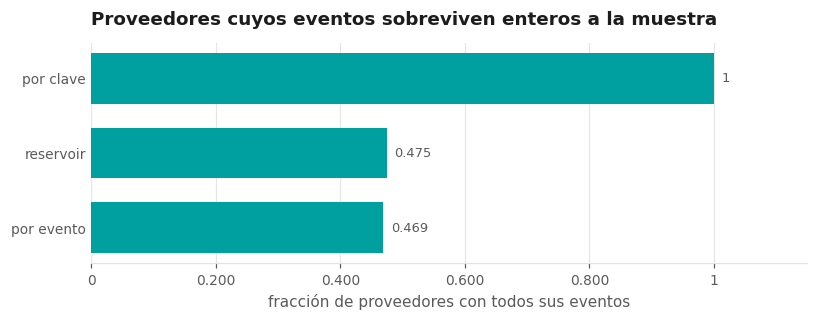

In [2]:
rng = np.random.default_rng(0)
FRAC = 0.10

por_evento = [e for e in eventos if rng.random() < FRAC]
por_clave = muestreo_por_clave(eventos, lambda e: e["proveedor_id"], FRAC)
de_reservoir = reservoir(eventos, k=len(eventos) // 10, semilla=0)

exacto_prov = Counter(e["proveedor_id"] for e in eventos if e["proveedor_id"])


def completos(muestra):
    """Que fraccion de los proveedores de la muestra conserva TODOS sus eventos."""
    c = Counter(e["proveedor_id"] for e in muestra if e["proveedor_id"])
    return np.mean([c[p] == exacto_prov[p] for p in c]) if c else 0.0


comp = pd.DataFrame([
    {"tecnica": "por evento", "eventos": len(por_evento),
     "proveedores": len({e["proveedor_id"] for e in por_evento if e["proveedor_id"]}),
     "proveedores_completos": round(completos(por_evento), 4)},
    {"tecnica": "por clave", "eventos": len(por_clave),
     "proveedores": len({e["proveedor_id"] for e in por_clave if e["proveedor_id"]}),
     "proveedores_completos": round(completos(por_clave), 4)},
    {"tecnica": "reservoir", "eventos": len(de_reservoir),
     "proveedores": len({e["proveedor_id"] for e in de_reservoir if e["proveedor_id"]}),
     "proveedores_completos": round(completos(de_reservoir), 4)}])
exportar(comp, "p4_muestreo", "Tres tecnicas de muestreo y que preguntas sobreviven")

fig, _ = barras_h(comp, "tecnica", "proveedores_completos",
                  "Proveedores cuyos eventos sobreviven enteros a la muestra",
                  "fracción de proveedores con todos sus eventos", color=TEAL, alto=0.5)
pe = comp[comp.tecnica == "por evento"].iloc[0]; pc = comp[comp.tecnica == "por clave"].iloc[0]
figura(fig, "f27_muestreo", f"""
Los tres conservan aproximadamente el mismo número de eventos, así que por tamaño son
equivalentes. Por utilidad no lo son en absoluto. Con muestreo por evento solo el
{100*pe.proveedores_completos:.1f} % de los proveedores queda completo, de modo que cualquier
pregunta del tipo cuántas adjudicaciones acumuló este proveedor da una respuesta falsa sobre la
muestra. Con muestreo por clave el {100*pc.proveedores_completos:.0f} % queda completo, porque
la entidad entra entera o no entra. El reservoir se comporta como el muestreo por evento, que es
lo esperado: su garantía es de uniformidad sobre eventos, no de integridad por entidad.""")
comp

Entonces la elección entre reservoir y muestreo por clave no se decide por precisión sino por la pregunta. Reservoir sirve cuando interesa una muestra representativa del flujo con memoria acotada y no se conoce su largo. Muestreo por clave sirve cuando las preguntas son por entidad. Para este proyecto hacen falta los dos, y por eso se implementan los dos.


Lectura de f28_reservoir
Verificación empírica de la garantía teórica. El invariante del reservoir es que, tras ver i elementos, cada uno está en la muestra con probabilidad k sobre i, y eso implica que la composición de la muestra debe reproducir la del flujo. La desviación máxima entre ambas distribuciones es de 0.06 puntos porcentuales sobre los ocho métodos más frecuentes, lo que confirma que la muestra es utilizable para estimar proporciones aunque no sirva para preguntas por entidad.



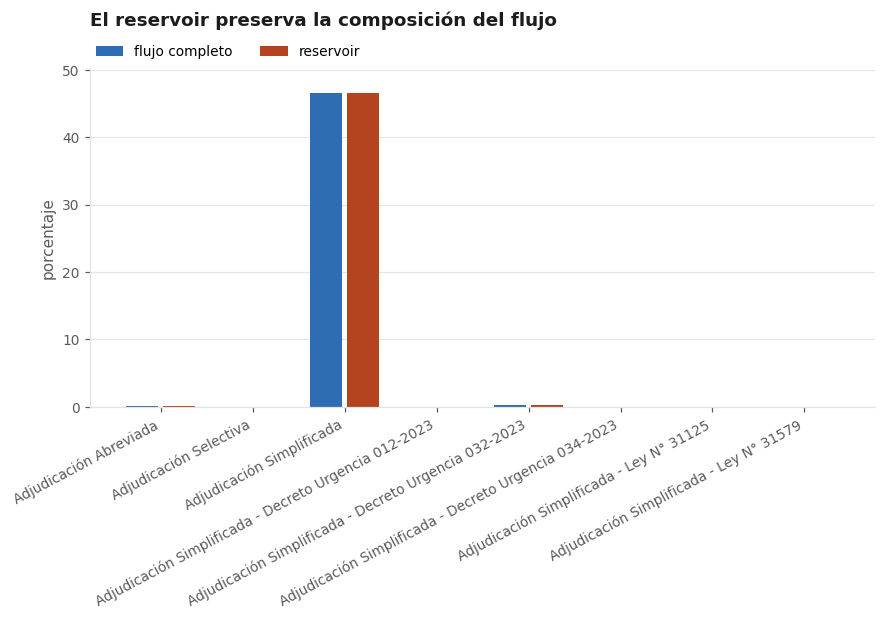

In [3]:
# El reservoir si cumple lo que promete: preservar la distribucion del flujo.
dist = pd.DataFrame({
    "flujo completo": pd.Series([e["metodo"] for e in eventos]).value_counts(normalize=True),
    "reservoir": pd.Series([e["metodo"] for e in de_reservoir]).value_counts(normalize=True),
}).head(8).fillna(0) * 100
dist = dist.reset_index(names="metodo")
exportar(dist.round(3), "p4_reservoir_distribucion", "Distribucion de metodos en el flujo y en el reservoir")

fig, _ = barras_agrupadas(dist, "metodo", ["flujo completo", "reservoir"],
                          "El reservoir preserva la composición del flujo", "porcentaje")
desvio = float((dist["flujo completo"] - dist["reservoir"]).abs().max())
figura(fig, "f28_reservoir", f"""
Verificación empírica de la garantía teórica. El invariante del reservoir es que, tras ver i
elementos, cada uno está en la muestra con probabilidad k sobre i, y eso implica que la
composición de la muestra debe reproducir la del flujo. La desviación máxima entre ambas
distribuciones es de {desvio:.2f} puntos porcentuales sobre los ocho métodos más frecuentes, lo
que confirma que la muestra es utilizable para estimar proporciones aunque no sirva para
preguntas por entidad.""")

## 2. Bloom Filter: ha aparecido antes este proveedor

Tarea concreta: detectar reapariciones sin mantener el conjunto de todos los proveedores vistos. El filtro nunca dice que no a algo que sí estaba, de modo que un negativo es definitivo. Un positivo puede ser falso, con probabilidad que se calcula de antemano.

146,025 apariciones de 67,510 proveedores distintos



Lectura de f29_bloom
La curva observada sigue a la teórica, lo que valida la implementación. Lo que decide es la comparación con la alternativa exacta: guardar los 67,510 identificadores en un conjunto de Python costaría del orden de 1,582 KiB, mientras que el filtro con 1 % de falsos positivos ocupa 79.0 KiB, unas 20 veces menos. Los falsos negativos observados son 0 en todas las configuraciones, como garantiza la construcción. Bajar de 1 % a 0,1 % cuesta un 50 % más de memoria, así que el punto razonable depende de qué se haga con un falso positivo.



,fpr_objetivo,m_bits,k_hashes,memoria_kib,fpr_teorica,fpr_observada,falsos_negativos
0,0.200,226148,2,27.6,0.52580,0.07848,0
1,0.100,323544,3,39.5,0.40817,0.03062,0
2,0.050,420940,4,51.4,0.31696,0.01261,0
3,0.010,647088,7,79.0,0.19887,0.00172,0
4,0.001,970631,10,118.5,0.08110,0.00012,0


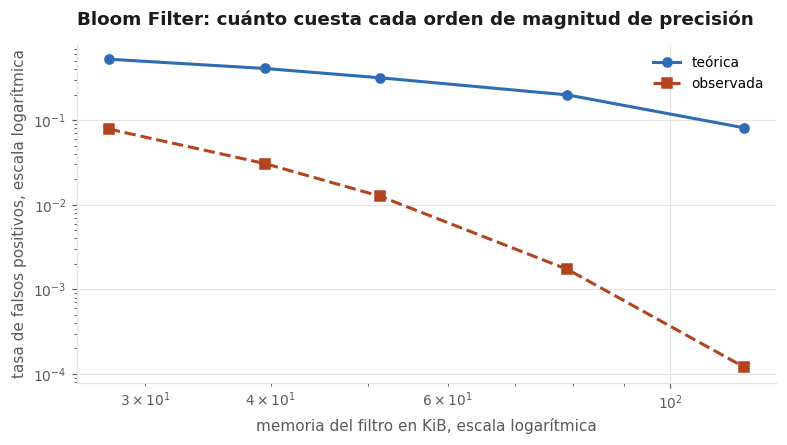

In [4]:
provs = [e["proveedor_id"] for e in eventos if e["proveedor_id"]]
distintos = len(set(provs))
print(f"{len(provs):,} apariciones de {distintos:,} proveedores distintos")

filas = []
for objetivo in (0.20, 0.10, 0.05, 0.01, 0.001):
    bf = BloomFilter(n_esperado=distintos, fpr_objetivo=objetivo)
    vistos, falsos, negativos, reapariciones = set(), 0, 0, 0
    for p in provs:
        esta = p in bf
        if esta and p not in vistos:
            falsos += 1
        if not esta and p in vistos:
            negativos += 1           # imposible por construccion
        if p in vistos:
            reapariciones += 1
        vistos.add(p); bf.agregar(p)
    nuevos = len(provs) - reapariciones
    filas.append({"fpr_objetivo": objetivo, "m_bits": bf.m, "k_hashes": bf.k,
                  "memoria_kib": round(bf.bytes_usados / 1024, 1),
                  "fpr_teorica": round(bf.fpr_teorica(), 5),
                  "fpr_observada": round(falsos / nuevos, 5),
                  "falsos_negativos": negativos})
bloom = pd.DataFrame(filas)
exportar(bloom, "p4_bloom", "Bloom Filter: memoria frente a tasa de falsos positivos")

fig, ax = plt.subplots(figsize=(8.2, 4))
ax.plot(bloom.memoria_kib, bloom.fpr_teorica, "o-", color=AZUL, lw=2, label="teórica")
ax.plot(bloom.memoria_kib, bloom.fpr_observada, "s--", color=ROJO, lw=2, label="observada")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("memoria del filtro en KiB, escala logarítmica")
ax.set_ylabel("tasa de falsos positivos, escala logarítmica")
ax.set_title("Bloom Filter: cuánto cuesta cada orden de magnitud de precisión", loc="left", pad=12)
ax.grid(alpha=.9); ax.set_axisbelow(True); ax.legend()
exacto_kib = distintos * 24 / 1024
b1 = bloom[bloom.fpr_objetivo == 0.01].iloc[0]
figura(fig, "f29_bloom", f"""
La curva observada sigue a la teórica, lo que valida la implementación. Lo que decide es la
comparación con la alternativa exacta: guardar los {distintos:,} identificadores en un conjunto
de Python costaría del orden de {exacto_kib:,.0f} KiB, mientras que el filtro con 1 % de falsos
positivos ocupa {b1.memoria_kib:,.1f} KiB, unas {exacto_kib/b1.memoria_kib:.0f} veces menos.
Los falsos negativos observados son {int(bloom.falsos_negativos.sum())} en todas las
configuraciones, como garantiza la construcción. Bajar de 1 % a 0,1 % cuesta un 50 % más de
memoria, así que el punto razonable depende de qué se haga con un falso positivo.""")
bloom

## 3. Count-Min Sketch: cuántas veces apareció cada ítem

Tarea concreta: estimar la frecuencia de cada código CUBSO sin mantener un diccionario de miles de claves. El sketch nunca subestima, porque cada celda acumula la clave más sus colisiones y el estimador toma el mínimo de las filas.

132,091 apariciones de 4,664 codigos CUBSO distintos



Lectura de f30_cms
El error observado queda siempre por debajo de la cota teórica, y nunca hay subestimaciones (0 en total), que es exactamente lo que garantiza tomar el mínimo de las filas. El ancho controla el error y la profundidad la probabilidad de excederlo. Pasar de 15 KiB a 1,487 KiB baja el error máximo de 480.0 a 2.0 apariciones. Para comparar: el diccionario exacto de 4,664 códigos ocupa del orden de 273 KiB, así que aquí el sketch solo compensa si el universo de claves fuera mucho mayor, y eso hay que decirlo.



,epsilon,ancho_w,profundidad_d,memoria_kib,error_medio,error_max,cota_teorica,subestimaciones
0,0.0100,272,7,14.9,97.24,480,1320,0
1,0.0050,544,7,29.8,30.70,319,660,0
2,0.0010,2719,7,148.7,0.57,19,132,0
3,0.0005,5437,7,297.3,0.04,8,66,0
4,0.0001,27183,7,1486.6,0.00,2,13,0


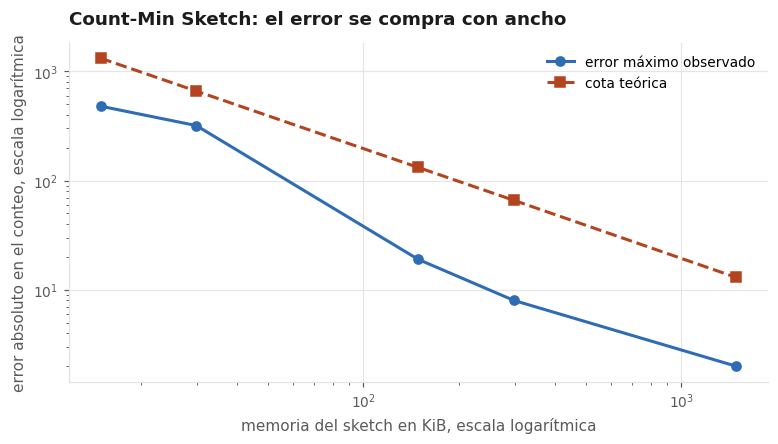

In [5]:
items = [i for e in eventos for i in e["items"]]
exacto_items = Counter(items)
print(f"{len(items):,} apariciones de {len(exacto_items):,} codigos CUBSO distintos")

filas = []
for eps in (1e-2, 5e-3, 1e-3, 5e-4, 1e-4):
    cms = CountMinSketch(epsilon=eps, delta=1e-3)
    for i in items:
        cms.agregar(i)
    errs = np.array([cms.estimar(k) - v for k, v in exacto_items.items()])
    filas.append({"epsilon": eps, "ancho_w": cms.w, "profundidad_d": cms.d,
                  "memoria_kib": round(cms.bytes_usados / 1024, 1),
                  "error_medio": round(float(errs.mean()), 2),
                  "error_max": int(errs.max()),
                  "cota_teorica": int(cms.error_teorico()),
                  "subestimaciones": int((errs < 0).sum())})
cms_df = pd.DataFrame(filas)
exportar(cms_df, "p4_cms", "Count-Min Sketch: memoria frente a error de frecuencia")

fig, ax = plt.subplots(figsize=(8.2, 4))
ax.plot(cms_df.memoria_kib, cms_df.error_max, "o-", color=AZUL, lw=2, label="error máximo observado")
ax.plot(cms_df.memoria_kib, cms_df.cota_teorica, "s--", color=ROJO, lw=2, label="cota teórica")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("memoria del sketch en KiB, escala logarítmica")
ax.set_ylabel("error absoluto en el conteo, escala logarítmica")
ax.set_title("Count-Min Sketch: el error se compra con ancho", loc="left", pad=12)
ax.grid(alpha=.9); ax.set_axisbelow(True); ax.legend()
c_fino = cms_df.iloc[-1]; c_basto = cms_df.iloc[0]
exacto_items_kib = len(exacto_items) * 60 / 1024
figura(fig, "f30_cms", f"""
El error observado queda siempre por debajo de la cota teórica, y nunca hay subestimaciones
({int(cms_df.subestimaciones.sum())} en total), que es exactamente lo que garantiza tomar el
mínimo de las filas. El ancho controla el error y la profundidad la probabilidad de excederlo.
Pasar de {c_basto.memoria_kib:,.0f} KiB a {c_fino.memoria_kib:,.0f} KiB baja el error máximo de
{c_basto.error_max:,} a {c_fino.error_max:,} apariciones. Para comparar: el diccionario exacto
de {len(exacto_items):,} códigos ocupa del orden de {exacto_items_kib:,.0f} KiB, así que aquí el
sketch solo compensa si el universo de claves fuera mucho mayor, y eso hay que decirlo.""")
cms_df

## 4. Por qué hacen falta los dos, y no uno de los dos

Es la pregunta natural: el Count-Min Sketch estima frecuencias, y una frecuencia mayor que cero es una respuesta de pertenencia. Entonces para qué un Bloom Filter.

La respuesta es que resuelven preguntas distintas y el costo de forzar una sobre la otra es alto. Un Bloom Filter guarda un bit por posición; un Count-Min guarda un contador de ocho bytes. Para la misma tarea de pertenencia con la misma tasa de error, el sketch necesita sesenta y cuatro veces más memoria por celda, y además responde mal: una celda con valor positivo por colisión declara presente a un elemento ausente igual que el Bloom, sin ganar nada a cambio.

Bloom: m=647,088 bits, k=7
Count-Min dimensionado para la misma tarea: w=92,518, d=7



Lectura de f31_bloom_vs_cms
El Count-Min se dimensionó resolviendo su propia fórmula de colisión para que alcance la misma tasa de falsos positivos que el Bloom, no eligiendo parámetros a ojo. Con tasas equivalentes (0.0017 frente a 0.0017), necesita 5,060 KiB contra 79.0 KiB, es decir 64 veces más, y la razón es estructural: guarda un contador de ocho bytes donde al otro le basta un bit. No se sustituyen. El Bloom es la estructura correcta cuando la pregunta es si algo apareció; el Count-Min cuando la pregunta es cuántas veces. Usar el segundo para lo primero es pagar sesenta y cuatro veces por la misma respuesta.



,estructura,responde,memoria_kib,fpr_observada
0,Bloom Filter,pertenencia,79.0,0.00172
1,Count-Min Sketch,frecuencia,5059.6,0.00167


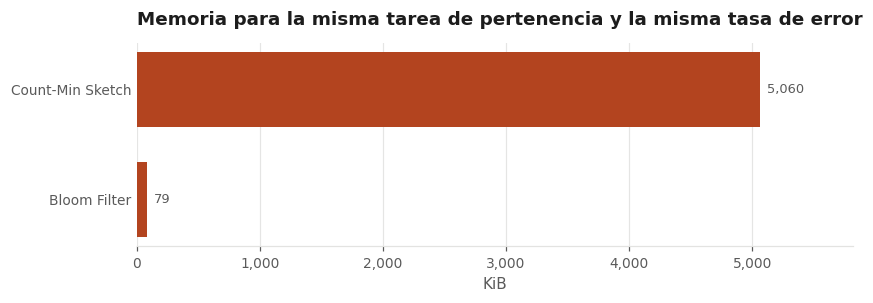

In [6]:
def dimensionar_cms_pertenencia(n, fpr, max_d=8):
    """Ancho y profundidad para que un Count-Min responda pertenencia con esa tasa.

    Un elemento ausente se declara presente solo si las d filas tienen su celda
    ocupada. Con n claves repartidas en w columnas, una celda esta ocupada con
    probabilidad 1 - exp(-n/w), asi que hay que resolver (1-exp(-n/w))^d = fpr.
    Se recorre d y se elige la combinacion de menor memoria.
    """
    opciones = []
    for d in range(1, max_d + 1):
        w = int(np.ceil(n / -np.log(1 - fpr ** (1 / d))))
        opciones.append((d * w * 8, w, d))
    _, w, d = min(opciones)
    return w, d


FPR = 0.01
bf = BloomFilter(n_esperado=distintos, fpr_objetivo=FPR)
w, d = dimensionar_cms_pertenencia(distintos, FPR)
cms_pert = CountMinSketch(w=w, d=d)
print(f"Bloom: m={bf.m:,} bits, k={bf.k}")
print(f"Count-Min dimensionado para la misma tarea: w={w:,}, d={d}")

vistos, fp_bf, fp_cms, nuevos = set(), 0, 0, 0
for prov in provs:
    if prov not in vistos:
        nuevos += 1
        fp_bf += prov in bf
        fp_cms += cms_pert.estimar(prov) > 0
    vistos.add(prov); bf.agregar(prov); cms_pert.agregar(prov)

duelo = pd.DataFrame([
    {"estructura": "Bloom Filter", "responde": "pertenencia",
     "memoria_kib": round(bf.bytes_usados / 1024, 1),
     "fpr_observada": round(fp_bf / nuevos, 5)},
    {"estructura": "Count-Min Sketch", "responde": "frecuencia",
     "memoria_kib": round(cms_pert.bytes_usados / 1024, 1),
     "fpr_observada": round(fp_cms / nuevos, 5)}])
exportar(duelo, "p4_bloom_vs_cms", "Bloom y Count-Min sobre la misma tarea de pertenencia")

fig, _ = barras_h(duelo, "estructura", "memoria_kib",
                  "Memoria para la misma tarea de pertenencia y la misma tasa de error",
                  "KiB", color=ROJO, alto=0.5)
fila_bf, fila_cms = duelo.iloc[0], duelo.iloc[1]
figura(fig, "f31_bloom_vs_cms", f"""
El Count-Min se dimensionó resolviendo su propia fórmula de colisión para que alcance la misma
tasa de falsos positivos que el Bloom, no eligiendo parámetros a ojo. Con tasas equivalentes
({fila_bf.fpr_observada:.4f} frente a {fila_cms.fpr_observada:.4f}), necesita
{fila_cms.memoria_kib:,.0f} KiB contra {fila_bf.memoria_kib:,.1f} KiB, es decir
{fila_cms.memoria_kib/fila_bf.memoria_kib:.0f} veces más, y la razón es estructural: guarda un
contador de ocho bytes donde al otro le basta un bit. No se sustituyen. El Bloom es la estructura
correcta cuando la pregunta es si algo apareció; el Count-Min cuando la pregunta es cuántas
veces. Usar el segundo para lo primero es pagar sesenta y cuatro veces por la misma respuesta.""")
duelo

## 5. DGIM: cuántos de los últimos N procesos tuvieron un solo postor

La pregunta de la Parte I quedó abierta: hay un suelo de procesos sin competencia que atraviesa todos los tramos de monto. Sobre un flujo, la pregunta útil es si ese suelo está subiendo o bajando ahora mismo, y eso es un conteo sobre una ventana reciente.

Guardar la ventana entera cuesta N bits. DGIM guarda cubos de tamaño potencia de dos, a lo más dos de cada tamaño, y eso baja la memoria a del orden de log cuadrado de N a cambio de un error relativo acotado por un medio.

21,785 de 177,398 procesos con un solo postor (12.3 %)



Lectura de f32_dgim
Las barras quedan casi a la misma altura en todas las ventanas: el peor error relativo es 25.0 % con N=50,000, muy por debajo de la cota teórica del 50 % que garantiza usar dos cubos por tamaño. Lo que compra ese error es la memoria: para la ventana de 150,000 elementos, DGIM usa 20 cubos, del orden de 320 bytes, frente a 18,750 bytes de la ventana completa en bits. Es una reducción de 59 veces, y crece con N porque la memoria de DGIM depende del logaritmo de la ventana y no de la ventana.



,ventana_N,exacto,dgim,error_relativo,cubos,memoria_dgim_bytes,memoria_exacta_bytes,dias_cubiertos,desde,hasta
0,500,200,193,0.0350,10,160,62,25,2025-12-05,2025-12-30
1,1000,291,313,0.0756,13,208,125,31,2025-11-28,2025-12-30
2,2500,556,665,0.1960,13,208,312,44,2025-11-15,2025-12-30
3,5000,879,793,0.0978,14,224,625,61,2025-10-29,2025-12-30
4,10000,1429,1561,0.0924,15,240,1250,89,2025-10-01,2025-12-30
5,20000,2498,2841,0.1373,16,256,2500,138,2025-08-14,2025-12-30
6,35000,4155,4377,0.0534,17,272,4375,238,2025-05-05,2025-12-30
7,50000,5959,7449,0.2500,18,288,6250,304,2025-02-28,2025-12-30
8,75000,9504,11545,0.2148,19,304,9375,467,2024-09-18,2025-12-30
9,100000,12120,11545,0.0474,19,304,12500,614,2024-04-25,2025-12-30


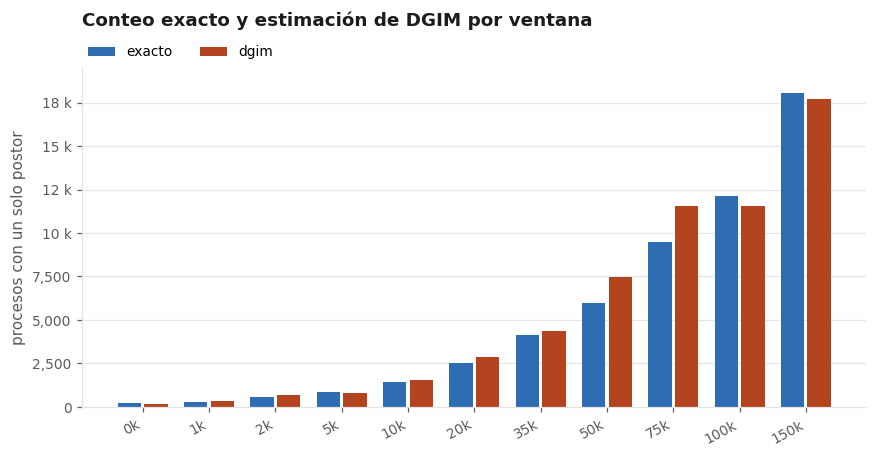

In [7]:
bits = [1 if (e["n_postores"] or 0) <= 1 else 0 for e in eventos]
print(f"{sum(bits):,} de {len(bits):,} procesos con un solo postor "
      f"({100*sum(bits)/len(bits):.1f} %)")

filas = []
fechas = [e["fecha"] for e in eventos]
for N in (500, 1_000, 2_500, 5_000, 10_000, 20_000, 35_000, 50_000, 75_000, 100_000, 150_000):
    d = DGIM(N, r=2)
    for bit in bits:
        d.agregar(bit)
    exacto = sum(bits[-N:])
    est = d.estimar()
    # La ventana es de N elementos, pero el flujo va ordenado por fecha, asi que
    # corresponde a un tramo temporal concreto. Se reporta en dias para poder
    # leerla como periodo reciente y no solo como un conteo de elementos.
    desde, hasta = fechas[-N], fechas[-1]
    filas.append({"ventana_N": N, "exacto": exacto, "dgim": est,
                  "error_relativo": round(abs(est - exacto) / max(exacto, 1), 4),
                  "cubos": d.n_cubos,
                  "memoria_dgim_bytes": d.n_cubos * 16,
                  "memoria_exacta_bytes": N // 8,
                  "dias_cubiertos": (hasta - desde).days,
                  "desde": str(desde.date()), "hasta": str(hasta.date())})
dgim_df = pd.DataFrame(filas)
exportar(dgim_df, "p4_dgim", "DGIM frente al conteo exacto sobre la ventana")

fig, _ = barras_agrupadas(dgim_df.assign(ventana_N=dgim_df.ventana_N.map(lambda x: f"{x//1000}k")),
                          "ventana_N", ["exacto", "dgim"],
                          "Conteo exacto y estimación de DGIM por ventana", "procesos con un solo postor")
peor = dgim_df.loc[dgim_df.error_relativo.idxmax()]
grande = dgim_df.iloc[-1]
figura(fig, "f32_dgim", f"""
Las barras quedan casi a la misma altura en todas las ventanas: el peor error relativo es
{100*peor.error_relativo:.1f} % con N={int(peor.ventana_N):,}, muy por debajo de la cota teórica
del 50 % que garantiza usar dos cubos por tamaño. Lo que compra ese error es la memoria: para la
ventana de {int(grande.ventana_N):,} elementos, DGIM usa {int(grande.cubos)} cubos, del orden de
{int(grande.memoria_dgim_bytes):,} bytes, frente a {int(grande.memoria_exacta_bytes):,} bytes de
la ventana completa en bits. Es una reducción de
{grande.memoria_exacta_bytes/grande.memoria_dgim_bytes:.0f} veces, y crece con N porque la
memoria de DGIM depende del logaritmo de la ventana y no de la ventana.""")
dgim_df


Lectura de f33_dgim_memoria
Las dos rectas divergen y ese es el argumento entero. Multiplicar la ventana por 300 multiplica la memoria exacta por lo mismo, mientras que los cubos de DGIM pasan solo de 10 a 20, porque su número depende del logaritmo de N. Con ventanas pequeñas DGIM no compensa, incluso pierde; el cruce aparece alrededor de los primeros miles de elementos y a partir de ahí la distancia solo crece.



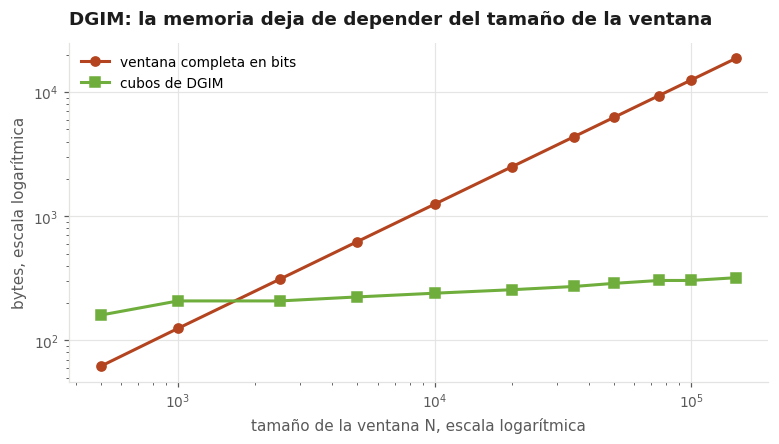

In [8]:
# El numero de cubos crece con el logaritmo de N, no con N.
fig, ax = plt.subplots(figsize=(8.2, 4))
ax.plot(dgim_df.ventana_N, dgim_df.memoria_exacta_bytes, "o-", color=ROJO, lw=2,
        label="ventana completa en bits")
ax.plot(dgim_df.ventana_N, dgim_df.memoria_dgim_bytes, "s-", color=VERDE, lw=2,
        label="cubos de DGIM")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("tamaño de la ventana N, escala logarítmica")
ax.set_ylabel("bytes, escala logarítmica")
ax.set_title("DGIM: la memoria deja de depender del tamaño de la ventana", loc="left", pad=12)
ax.grid(alpha=.9); ax.set_axisbelow(True); ax.legend(loc="upper left")
p0, p1 = dgim_df.iloc[0], dgim_df.iloc[-1]
figura(fig, "f33_dgim_memoria", f"""
Las dos rectas divergen y ese es el argumento entero. Multiplicar la ventana por
{p1.ventana_N/p0.ventana_N:.0f} multiplica la memoria exacta por lo mismo, mientras que los
cubos de DGIM pasan solo de {int(p0.cubos)} a {int(p1.cubos)}, porque su número depende del
logaritmo de N. Con ventanas pequeñas DGIM no compensa, incluso pierde; el cruce aparece
alrededor de los primeros miles de elementos y a partir de ahí la distancia solo crece.""")

## 6. DGIM frente a reservoir: tampoco son alternativas

Se confunden porque ambos son resúmenes de un flujo con memoria acotada, pero responden a preguntas ortogonales. El reservoir da una muestra uniforme de todo el flujo, sin noción de recencia: un evento de 2023 tiene la misma probabilidad de estar que uno de 2025. DGIM responde solo sobre los últimos N elementos y olvida el resto por construcción.

In [9]:
N = 20_000
exacto_ventana = sum(bits[-N:])
muestra_r = reservoir(list(enumerate(bits)), k=N // 10, semilla=1)
# Si se intenta responder la pregunta de ventana con el reservoir, hay que
# filtrar sus elementos por posicion, y quedan muy pocos.
en_ventana = [b for i, b in muestra_r if i >= len(bits) - N]
estimado_r = len(en_ventana) and sum(en_ventana) * N / len(en_ventana)

d = DGIM(N, r=2)
for bit in bits:
    d.agregar(bit)

cara = pd.DataFrame([
    {"metodo": "conteo exacto", "estimacion": exacto_ventana,
     "memoria_bytes": N // 8, "responde_ventana": True},
    {"metodo": "DGIM", "estimacion": d.estimar(),
     "memoria_bytes": d.n_cubos * 16, "responde_ventana": True},
    {"metodo": "reservoir filtrado", "estimacion": int(estimado_r),
     "memoria_bytes": (N // 10) * 16, "responde_ventana": False}])
cara["error_pct"] = (100 * (cara.estimacion - exacto_ventana).abs() / exacto_ventana).round(2)
exportar(cara, "p4_dgim_vs_reservoir", "DGIM y reservoir sobre la pregunta de ventana reciente")
print(f"elementos del reservoir que caen en la ventana: {len(en_ventana)} de {N//10}")
cara

elementos del reservoir que caen en la ventana: 234 de 2000


,metodo,estimacion,memoria_bytes,responde_ventana,error_pct
0,conteo exacto,2498,2500,True,0.00
1,DGIM,2841,256,True,13.73
2,reservoir filtrado,2820,32000,False,12.89


El reservoir puede aproximar la pregunta de ventana solo descartando casi toda su muestra, y lo hace con más memoria y más error que DGIM. A la inversa, DGIM no puede responder qué proporción de todo el histórico tuvo un solo postor, porque ya olvidó el histórico. Por eso el proyecto implementa los dos: reservoir para las preguntas sobre el flujo completo, DGIM para las preguntas sobre lo reciente.

## 7. Cuánto cuesta cada estructura en tiempo

El enunciado pide analizar precisión, memoria y tiempo. Las dos primeras ya están medidas por estructura; falta la tercera. Se cronometra el recorrido completo del flujo, que es el único régimen que importa aquí: en un flujo cada elemento se ve una vez, de modo que lo que decide es el costo por elemento y no el de una consulta aislada.


Lectura de f38_tiempos_estructuras
El tiempo es la tercera dimensión del compromiso, junto a precisión y memoria, y conviene mirarla antes de celebrar el ahorro de memoria. El filtro de Bloom cuesta 7.35 microsegundos por elemento frente a 0.08 del conjunto exacto de Python, es decir 91.9 veces más, porque calcula varias funciones hash donde el conjunto nativo calcula una sola y está implementado en C. La conclusión honesta es que estas estructuras no ahorran tiempo: cambian memoria por tiempo y por un error acotado, y se eligen cuando la memoria es el recurso escaso.



,estructura,elementos,segundos,microseg_por_elemento
0,Bloom Filter,146025,1.074,7.35
1,"Conjunto exacto, de referencia",146025,0.011,0.08
2,Count-Min Sketch,132091,1.023,7.74
3,"DGIM, ventana de 20.000",177398,0.091,0.51
4,Reservoir sampling,177398,0.195,1.10
5,Muestreo por clave,177398,0.165,0.93


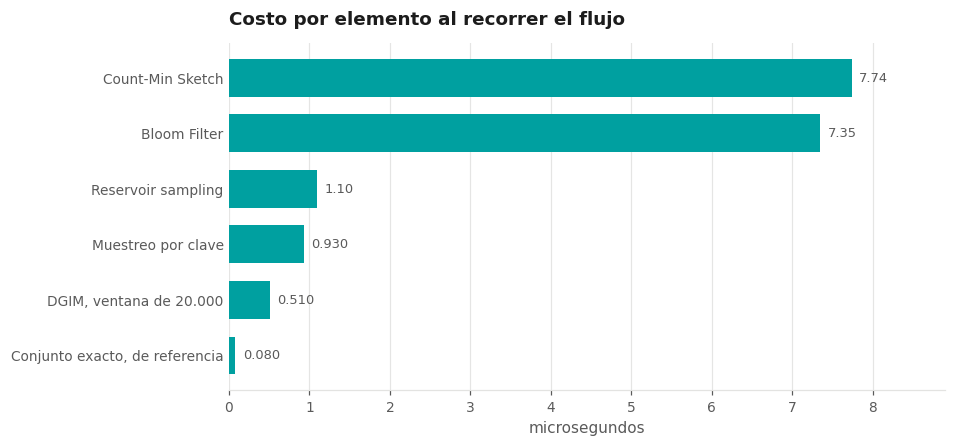

In [10]:
def cronometrar(nombre, construir, elementos):
    """Microsegundos por elemento al recorrer el flujo completo."""
    t0 = time.perf_counter()
    construir()
    dt = time.perf_counter() - t0
    return {"estructura": nombre, "elementos": elementos, "segundos": round(dt, 3),
            "microseg_por_elemento": round(dt / elementos * 1e6, 2)}


def _bloom():
    bf2 = BloomFilter(n_esperado=distintos, fpr_objetivo=0.01)
    for x in provs:
        x in bf2
        bf2.agregar(x)

def _conjunto_exacto():
    vistos2 = set()
    for x in provs:
        x in vistos2
        vistos2.add(x)

def _cms():
    c2 = CountMinSketch(epsilon=1e-3, delta=1e-3)
    for i in items:
        c2.agregar(i)

def _dgim():
    d2 = DGIM(20_000, r=2)
    for b in bits:
        d2.agregar(b)

tiempos = pd.DataFrame([
    cronometrar("Bloom Filter", _bloom, len(provs)),
    cronometrar("Conjunto exacto, de referencia", _conjunto_exacto, len(provs)),
    cronometrar("Count-Min Sketch", _cms, len(items)),
    cronometrar("DGIM, ventana de 20.000", _dgim, len(bits)),
    cronometrar("Reservoir sampling", lambda: reservoir(eventos, len(eventos) // 10, 0), len(eventos)),
    cronometrar("Muestreo por clave", lambda: muestreo_por_clave(
        eventos, lambda e: e["proveedor_id"], 0.10), len(eventos)),
])
exportar(tiempos, "p4_tiempos", "Costo en tiempo de cada estructura al recorrer el flujo")

fig, _ = barras_h(tiempos, "estructura", "microseg_por_elemento",
                  "Costo por elemento al recorrer el flujo", "microsegundos",
                  color=TEAL, alto=0.5)
bf_t = tiempos[tiempos.estructura == "Bloom Filter"].microseg_por_elemento.iloc[0]
ex_t = tiempos[tiempos.estructura.str.startswith("Conjunto exacto")].microseg_por_elemento.iloc[0]
figura(fig, "f38_tiempos_estructuras", f"""
El tiempo es la tercera dimensión del compromiso, junto a precisión y memoria, y conviene mirarla
antes de celebrar el ahorro de memoria. El filtro de Bloom cuesta {bf_t:.2f} microsegundos por
elemento frente a {ex_t:.2f} del conjunto exacto de Python, es decir {bf_t/ex_t:.1f} veces más,
porque calcula varias funciones hash donde el conjunto nativo calcula una sola y está implementado
en C. La conclusión honesta es que estas estructuras no ahorran tiempo: cambian memoria por tiempo
y por un error acotado, y se eligen cuando la memoria es el recurso escaso.""")
tiempos

## 8. Las cinco estructuras, lado a lado

La tabla es el entregable de esta parte: no cuál es mejor, sino qué pregunta responde cada una y qué cuesta.

In [11]:
tiempo_de = dict(zip(tiempos.estructura, tiempos.microseg_por_elemento))
resumen = pd.DataFrame([
    {"estructura": "Muestreo por clave", "tiempo": f"{tiempo_de['Muestreo por clave']:.2f} us", "pregunta": "métricas por entidad sobre una muestra",
     "memoria": "proporcional a la fracción de claves",
     "error": "ninguno dentro de las claves elegidas",
     "por_que_se_usa": "es la unica que conserva entidades completas"},
    {"estructura": "Reservoir sampling", "tiempo": f"{tiempo_de['Reservoir sampling']:.2f} us", "pregunta": "proporciones sobre todo el flujo",
     "memoria": "k elementos, fija y conocida de antemano",
     "error": f"desviacion maxima {desvio:.2f} puntos en la composicion",
     "por_que_se_usa": "no necesita conocer el largo del flujo"},
    {"estructura": "Bloom Filter", "tiempo": f"{tiempo_de['Bloom Filter']:.2f} us", "pregunta": "apareció antes este proveedor",
     "memoria": f"{fila_bf.memoria_kib:,.1f} KiB para {distintos:,} claves",
     "error": f"{fila_bf.fpr_observada:.3%} de falsos positivos, cero falsos negativos",
     "por_que_se_usa": "un bit por posicion, imbatible en pertenencia"},
    {"estructura": "Count-Min Sketch", "tiempo": f"{tiempo_de['Count-Min Sketch']:.2f} us", "pregunta": "cuántas veces apareció cada ítem",
     "memoria": f"{cms_df.iloc[2].memoria_kib:,.0f} KiB",
     "error": f"nunca subestima, maximo {int(cms_df.iloc[2].error_max)} apariciones",
     "por_que_se_usa": "unica que da frecuencias sin diccionario"},
    {"estructura": "DGIM", "tiempo": f"{tiempo_de['DGIM, ventana de 20.000']:.2f} us", "pregunta": "cuántos en los últimos N elementos",
     "memoria": f"{int(grande.cubos)} cubos para N={int(grande.ventana_N):,}",
     "error": f"{100*peor.error_relativo:.1f}% observado, cota teorica 50%",
     "por_que_se_usa": "unica con noción de recencia"}])
exportar(resumen, "p4_resumen", "Las cinco estructuras de resumen y su compromiso")

exportar(pd.DataFrame([{"claves_bloom": distintos, "eventos_items": len(items),
                        "claves_items": len(exacto_items), "eventos_flujo": len(eventos)}]),
         "p4_escalares", "Cardinalidades del flujo para el reporte interactivo de la Parte VI")
resumen

,estructura,tiempo,pregunta,memoria,error,por_que_se_usa
0,Muestreo por clave,0.93 us,métricas por entidad sobre una muestra,proporcional a la fracción de claves,ninguno dentro de las claves elegidas,es la unica que conserva entidades completas
1,Reservoir sampling,1.10 us,proporciones sobre todo el flujo,"k elementos, fija y conocida de antemano",desviacion maxima 0.06 puntos en la composicion,no necesita conocer el largo del flujo
2,Bloom Filter,7.35 us,apareció antes este proveedor,"79.0 KiB para 67,510 claves","0.172% de falsos positivos, cero falsos negativos","un bit por posicion, imbatible en pertenencia"
3,Count-Min Sketch,7.74 us,cuántas veces apareció cada ítem,149 KiB,"nunca subestima, maximo 19 apariciones",unica que da frecuencias sin diccionario
4,DGIM,0.51 us,cuántos en los últimos N elementos,"20 cubos para N=150,000","25.0% observado, cota teorica 50%",unica con noción de recencia


## 9. Cierre

1. Ninguna de las cinco sustituye a otra. Tres responden preguntas distintas sobre el mismo flujo (pertenencia, frecuencia y recencia) y dos son estrategias de muestreo con garantías distintas (uniformidad sobre eventos frente a integridad por entidad).
2. Las ganancias de memoria son reales pero dependen del tamaño. Bloom gana desde el primer momento; DGIM empieza a ganar a partir de algunos miles de elementos; el Count-Min solo compensa cuando el universo de claves es grande, y a este volumen todavía no lo es. Decirlo es parte del análisis.
3. La estructura que más aporta a las preguntas del proyecto es DGIM, porque convierte el suelo de procesos sin competencia de la Parte I en algo que se puede vigilar en tiempo real sin guardar el histórico.

In [12]:
exportar(pd.DataFrame(FIGURAS), "p4_figuras", "Figuras de la Parte IV con su lectura")
print(pd.DataFrame(FIGURAS).to_string(index=False))

                 figura                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            lectura
           f27_muestreo                   Los tres conservan aproximadamente el mismo número de eventos, así que por tamaño son equivalentes. Por utilidad no lo son en absoluto. Con muestreo por evento solo el 46.9 % de los proveedores queda completo, de modo que cualquier pregunta del tipo cuántas adjudicaciones acumuló este proveedor da una respuesta falsa sobre la muestra. Co